# Багатоканальна система масового обслуговування

Написати програмне середовище моделювання багатоканальної системи масового обслуговування.
Багатоканальна система масового обслуговування є заданою з M вхідними потоками вимог, M чергами та L обслуговуючими приборами:
   1) інтервал часу між надходженням вимог на вхід системи для кожного з потоків – випадкова величина з функцією розподілу F(X) (параметри розподілу однакові для кожного потоку);
   2) час обслуговування вимоги на кожному з приборів – випадкова величина з функцією розподілу G(X) (параметри розподілу однакові для кожного прибору);
   3) для кожної черги задана максимально припустима довжина та дисципліна черги (LIFO або FIFO) (всі черги мають однакову максимальну довжину та дисципліну);
   4) стан системи в початковий момент t = 0 визначається кількістю вимог в системі.

Функціонування системи. На вхід багатоканальної системи масового обслуговування подається вимога. Якщо хоча б один з приборів вільний, то вимога обслуговується на цьому приборі. Якщо вільні одразу декілька приборів, вибір серед них здійснюється випадковим чином. Якщо всі прибори зайняті та хоча б в одній із черг є вільні місця (поточна довжина черги менша максимально припустимої довжини), то вимога становиться останньою в дану чергу. Якщо вільні місця є в декількох чергах, серед них обирається найменша або здійснюється випадковий вибір (за бажанням). Якщо в жодній із черг немає вільних місць (поточна довжина усіх черг дорівнює максимально припустимій довжині), то вимога залишає систему необслугованою. Якщо вимогу обслуговано на приборі, то вона залишає систему обслугованою. Якщо один з приборів звільнився та хоча б одна із черг непуста, то місце на приборі займає вимога з черги згідно до дисципліни черги. Якщо непусті одразу декілька черг, на прибор поступає вимога або з найдовшої черги, або з обраної випадковим чином (за бажанням). Якщо після звільнення якогось з приборів всі черги пусті, то прибор простоює, доки на вхід системи не буде подано нову вимогу.

Необхідно промоделювати роботу багатоканальної системи масового обслуговування на часовому інтервалі [0, T] (T – визначається користувачем). Задана періодичність збору статистики dt=T/K (K – кількість моментів збору статистики – визначається користувачем). Для кожного моменту часу t = dt*i (i=0,...,K) необхідно обчислити такі характеристики:
   1. Час простою кожного прибору tп; вірогідність простою кожного прибору Pп=tп/t.
   2. Час завантаження кожного прибору tз; вірогідність завантаження кожного прибору Pз=tз/t.
   3. Час повного завантаження системи tсз (час, коли завантажені всі прибори); вірогідність повного завантаження системи Pсз=tсз/t.
   4. Час неповного завантаження системи tснз (час, коли частина приборів завантажена, а частина простоює); вірогідність неповного завантаження системи Pснз=tснз/t.
   5. Кількість вимог, які були обслуговані до моменту часу  t: Nо; вірогідність обслуговування Pо=Nо/N (N – кількість вимог, що поступили до системи до моменту часу t);
   6. Кількість вимог, які залишили систему необслуговуваними до моменту t: Nн; вірогідність відмови Pн=Nн/N;
   7. Кількість вимог в системі, а також на кожному приборі й у кожній черзі;
   8. Максимальна та середня довжина кожної черги;
   9. Середній час перебування вимог в системі та окремо на кожному приборі й у кожній черзі.

Характеристики, що стосуються приборів, обчислювати для кожного прибору окремо. Аналогічно для черг. Усі характеристики вивести на графіки.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
class MultiChannelQueue:
    def __init__(self, arrival_rate: float, queue_limit: int, num_channels: int, time_limit: float, dt: float):
        """
        Initialize the multi-channel queue system.

        :param arrival_rate: Arrival rate (lambda) for the Poisson process.
        :param queue_limit: Maximum queue size.
        :param num_channels: Number of service channels.
        :param time_limit: Simulation time limit.
        :param dt: Time step for recording statistics.
        """
        self.arrival_rate = arrival_rate
        self.queue_limit = queue_limit
        self.num_channels = num_channels
        self.time_limit = time_limit
        self.dt = dt

        self.time = 0.0
        self.queue = []
        self.channel_busy_until = [0.0] * num_channels

        self.total_requests = 0
        self.served_requests = 0
        self.dropped_requests = 0
        self.idle_time = [0.0] * num_channels
        self.queue_lengths = []
        self.system_times = []

    def generate_interarrival_time(self) -> float:
        return np.random.exponential(1 / self.arrival_rate)

    @staticmethod
    def generate_service_time() -> float:
        alpha = 1.5
        beta = 0.9
        return np.random.weibull(alpha) * beta

    def process_arrival(self, current_time: float):
        self.total_requests += 1

        if len(self.queue) < self.queue_limit:
            self.queue.append(current_time)
        else:
            self.dropped_requests += 1

    def process_service(self, current_time: float):
        for i in range(self.num_channels):
            if current_time >= self.channel_busy_until[i]:
                if self.queue:
                    arrival_time = self.queue.pop(0)
                    service_time = self.generate_service_time()
                    self.channel_busy_until[i] = current_time + service_time
                    self.served_requests += 1
                    self.system_times.append(current_time - arrival_time + service_time)
                else:
                    self.idle_time[i] += self.dt

    def simulate(self):
        next_arrival = self.generate_interarrival_time()

        self.time += self.dt
        while self.time < self.time_limit:
            if self.time >= next_arrival:
                self.process_arrival(self.time)
                next_arrival += self.generate_interarrival_time()

            self.process_service(self.time)
            self.queue_lengths.append(len(self.queue))
            self.time += self.dt

    def calculate_statistics(self) -> tuple[float, ...]:
        """
        Calculate key statistics for the system.

        :return: Tuple containing idle probability, load probability,
                 loss probability, mean queue length, mean system time,
                 mean time in queue, mean time in service.
        """
        total_time = self.time_limit
        idle_probability = sum(self.idle_time) / (total_time * self.num_channels)
        load_probability = 1 - idle_probability
        loss_probability = self.dropped_requests / self.total_requests
        mean_queue_length = np.mean(self.queue_lengths)
        mean_system_time = np.mean(self.system_times)
        mean_time_in_queue = mean_system_time - np.mean([self.generate_service_time() for _ in range(100)])
        mean_time_in_service = mean_system_time - mean_time_in_queue

        return (
            idle_probability,
            load_probability,
            loss_probability,
            mean_queue_length,
            mean_system_time,
            mean_time_in_queue,
            mean_time_in_service,
        )

    def plot_statistics(self):
        """
        Plot key statistics such as queue length over time.
        """
        time_steps = np.arange(0, self.time_limit, self.dt)
        min_length = min(len(time_steps), len(self.queue_lengths))

        plt.figure(figsize=(10, 5))
        plt.plot(time_steps[:min_length], self.queue_lengths[:min_length], label="Queue Length")
        plt.title("Queue Length Over Time")
        plt.xlabel("Time")
        plt.ylabel("Queue Length")
        plt.legend()
        plt.grid()
        plt.show()

Idle Probability: 0.46600000000000363
Load Probability: 0.5339999999999964
Loss Probability: 0.02564102564102564
Mean Queue Length: 0.194
Mean System Time: 0.9012068727151364
Mean Time in Queue: 0.09254016642649487
Mean Time in Service: 0.8086667062886416


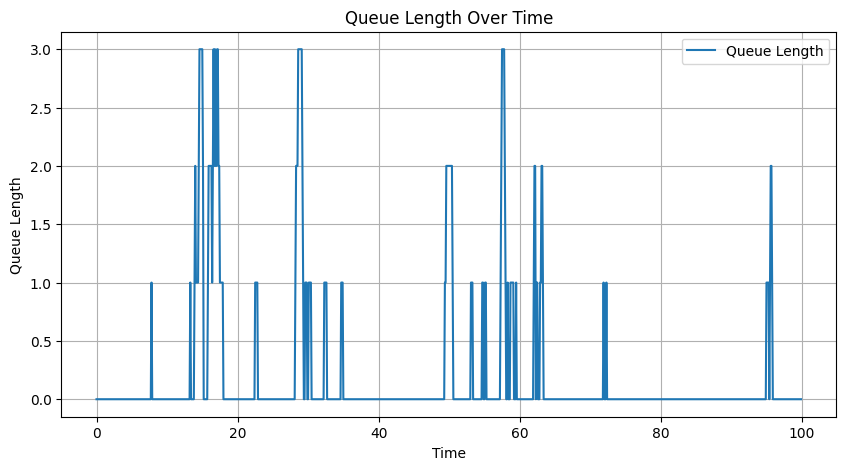

In [83]:
queue_system = MultiChannelQueue(
    arrival_rate=2,
    queue_limit=3,
    num_channels=3,
    time_limit=100.0,
    dt=.1
)
queue_system.simulate()

stats = queue_system.calculate_statistics()
print("Idle Probability:", stats[0])
print("Load Probability:", stats[1])
print("Loss Probability:", stats[2])
print("Mean Queue Length:", stats[3])
print("Mean System Time:", stats[4])
print("Mean Time in Queue:", stats[5])
print("Mean Time in Service:", stats[6])

queue_system.plot_statistics()